# Actividad 3 — EDA · INDECI

**Objetivo:** Analizar la distribucion de emergencias hidrometeorologicas, su relacion temporal con la produccion de limon y justificar su inclusion como variable exogena.

**Entrada:** Shapefiles INDECI 2021-2023 + resumen Excel
**Salidas:** Graficos en `pipeline/output/03_eda/act03_indeci_*.png`


## Configuracion inicial


In [1]:
import os, sys, json, glob, warnings, unicodedata
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

while not os.path.exists('pipeline/config/pipeline_config.json'):
    os.chdir('..')
with open('pipeline/config/pipeline_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)
SOURCES = CONFIG['sources']
OUTPUT  = CONFIG['output']
print('Config cargado OK | Raiz:', os.getcwd())


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-


## Carga de datos INDECI


In [2]:
import geopandas as gpd

def normalizar(t):
    import unicodedata
    if not isinstance(t, str): return ''
    t = unicodedata.normalize('NFKD', t).encode('ASCII','ignore').decode('utf-8')
    return t.upper().strip()

# Cargar shapefiles con columnas normalizadas
dfs_shp = []
for d in sorted(glob.glob(SOURCES['indeci_shapefiles'] + 'E_*/')):
    shp = glob.glob(d + '*.shp')
    if shp:
        gdf = gpd.read_file(shp[0])
        df_tmp = pd.DataFrame(gdf.drop(columns='geometry', errors='ignore'))
        df_tmp.columns = [str(c).lower() for c in df_tmp.columns]
        dfs_shp.append(df_tmp)
df_indeci = pd.concat(dfs_shp, ignore_index=True)

# Fenomenos relevantes para agricultura
FENOMENOS_AGRO = CONFIG['fenomenos_indeci']
df_agro = df_indeci[df_indeci['fenomeno'].str.upper().isin(
    [normalizar(f) for f in FENOMENOS_AGRO]
)].copy()

# Cargar produccion de limon para comparacion
xl = pd.ExcelFile(SOURCES['midagri'])
dfs_m = [pd.read_excel(SOURCES['midagri'], sheet_name=s) for s in xl.sheet_names]
df_m = pd.concat(dfs_m, ignore_index=True)
df_limon = df_m[df_m['dsc_Cultivo'].str.upper().str.contains('LIMON', na=False)].copy()
df_limon['fecha'] = pd.to_datetime(
    df_limon['anho'].astype(str) + '-' + df_limon['mes'].astype(str).str.zfill(2) + '-01'
)
prod_mensual = df_limon.groupby('fecha')['PRODUCCION(t)'].sum().reset_index()

print(f'INDECI total: {df_indeci.shape}')
print(f'INDECI solo fenomenos agro: {df_agro.shape}')
print(f'Fenomenos agro incluidos: {FENOMENOS_AGRO}')


INDECI total: (25025, 79)
INDECI solo fenomenos agro: (13487, 79)
Fenomenos agro incluidos: ['LLUVIAS INTENSAS', 'INUNDACION', 'HUAYCO', 'SEQUIA', 'HELADAS', 'FRIAJE', 'GRANIZADA', 'NEVADA', 'VIENTOS FUERTES', 'DESLIZAMIENTO', 'EROSION']


## 3.1 Grafico 1 — Fenomenos hidrometeorologicos por frecuencia


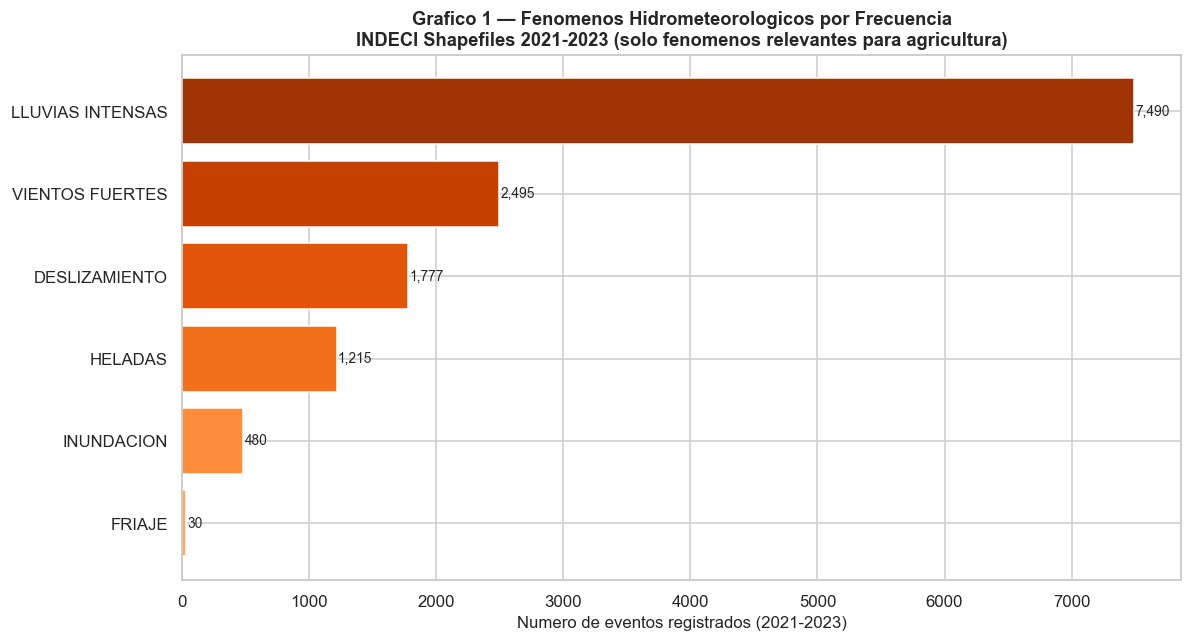

Guardado: pipeline/output/03_eda/act03_indeci_g1_fenomenos.png

Top 5 fenomenos:
fenomeno
INUNDACION           480
HELADAS             1215
DESLIZAMIENTO       1777
VIENTOS FUERTES     2495
LLUVIAS INTENSAS    7490


In [3]:
fen_counts = df_agro['fenomeno'].str.upper().value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
colors_fen = plt.cm.Oranges(np.linspace(0.4, 0.9, len(fen_counts)))
bars = ax.barh(fen_counts.index, fen_counts.values, color=colors_fen, edgecolor='white')
for bar, val in zip(bars, fen_counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_xlabel('Numero de eventos registrados (2021-2023)', fontsize=11)
ax.set_title('Grafico 1 — Fenomenos Hidrometeorologicos por Frecuencia\n'
             'INDECI Shapefiles 2021-2023 (solo fenomenos relevantes para agricultura)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_indeci_g1_fenomenos.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)
print()
print('Top 5 fenomenos:')
print(fen_counts.tail(5).to_string())


### Interpretacion

**Que muestra:** La frecuencia de cada tipo de fenomeno hidrometeorologico relevante para agricultura. Los fenomenos dominantes son los que mas impactan la produccion de limon.

**Implicacion para el pipeline:** En la Actividad 5 se filtrara el dataset INDECI conservando solo estos fenomenos. La distribucion de frecuencias justifica que el conteo mensual de emergencias es una variable informativa.

**Implicacion para el modelo:** Los fenomenos mas frecuentes (lluvias intensas, huaycos) son los que mas variabilidad aportan a la variable `num_emergencias`. El LSTM-Attention aprendera a asociar picos de emergencias con caidas de produccion.


## 3.2 Grafico 2 — Emergencias por departamento productor de limon


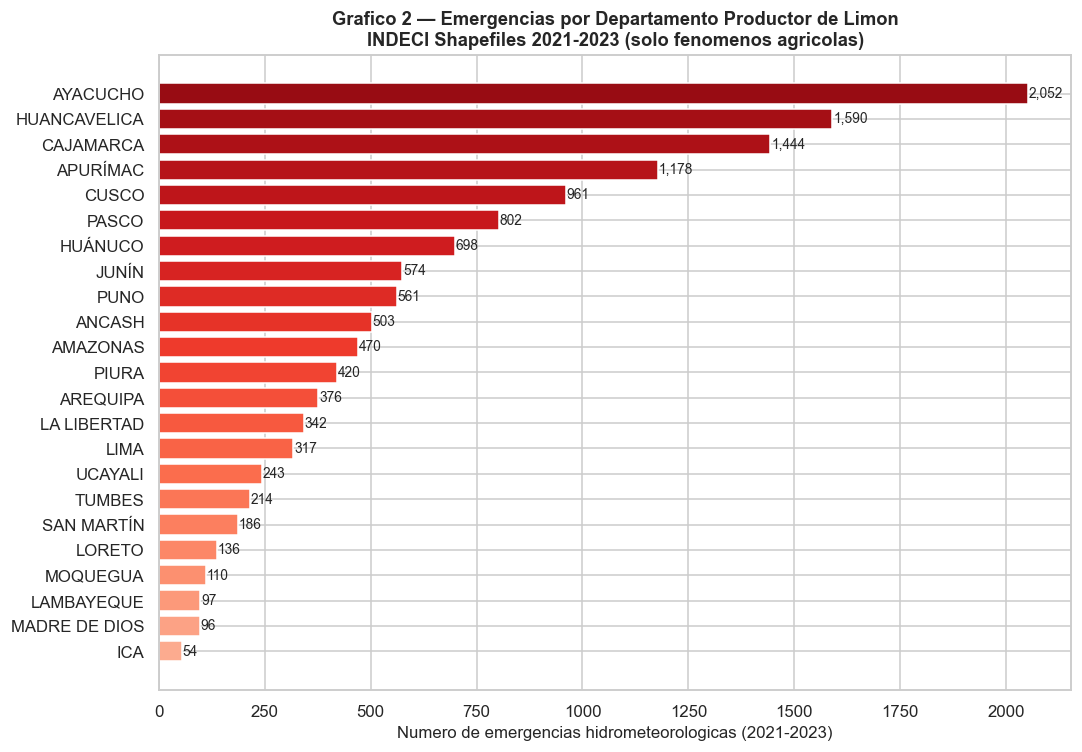

Guardado: pipeline/output/03_eda/act03_indeci_g2_dpto.png


In [4]:
# Obtener departamentos productores de limon
dptos_limon = set(normalizar(d) for d in df_limon['Dpto'].dropna().unique())

# Filtrar INDECI solo para departamentos limoneros
df_agro['dpto_norm'] = df_agro['departamen'].apply(normalizar)
df_limon_indeci = df_agro[df_agro['dpto_norm'].isin(dptos_limon)]

emer_dpto = df_limon_indeci['departamen'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors_d = plt.cm.Reds(np.linspace(0.3, 0.9, len(emer_dpto)))
bars = ax.barh(emer_dpto.index, emer_dpto.values, color=colors_d, edgecolor='white')
for bar, val in zip(bars, emer_dpto.values):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', va='center', fontsize=9)
ax.set_xlabel('Numero de emergencias hidrometeorologicas (2021-2023)', fontsize=11)
ax.set_title('Grafico 2 — Emergencias por Departamento Productor de Limon\n'
             'INDECI Shapefiles 2021-2023 (solo fenomenos agricolas)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g = OUTPUT['eda'] + 'act03_indeci_g2_dpto.png'
plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g)


### Interpretacion

**Que muestra:** La distribucion de emergencias hidrometeorologicas en los departamentos productores de limon. Los departamentos con mas emergencias son los que mas riesgo climatico tienen para la produccion.

**Implicacion para el pipeline:** Los departamentos con pocas emergencias tendran la variable `num_emergencias` cercana a cero en muchos meses, lo que puede reducir su poder predictivo. Se evaluara en la Actividad 9.

**Implicacion para el modelo:** La variabilidad geografica de las emergencias es lo que hace que esta variable sea informativa. Si todos los departamentos tuvieran el mismo numero de emergencias, no aportaria informacion al modelo.


## 3.3 Grafico 3 — Serie temporal de emergencias mensuales


In [5]:
# Construir serie mensual de emergencias
df_agro['fecha_evento'] = pd.to_datetime(
    df_agro['anho'].astype(str) + '-' + df_agro['mes'].astype(str).str.zfill(2) + '-01',
    errors='coerce'
)
serie_emer = df_agro.groupby('fecha_evento').size().reset_index(name='n_emergencias')
serie_emer = serie_emer.sort_values('fecha_evento').dropna(subset=['fecha_evento'])

if len(serie_emer) == 0:
    print('Sin datos de emergencias con fecha valida. Verificar columnas anho/mes.')
else:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(serie_emer['fecha_evento'], serie_emer['n_emergencias'],
           color='#e67e22', edgecolor='white', width=20, alpha=0.85)
    ax.plot(serie_emer['fecha_evento'], serie_emer['n_emergencias'],
            color='#d35400', linewidth=1.5, marker='o', markersize=3)

    if len(serie_emer) > 0:
        idx_pico = serie_emer['n_emergencias'].idxmax()
        ax.annotate(
            f'Pico: {serie_emer.loc[idx_pico,"n_emergencias"]:,}',
            xy=(serie_emer.loc[idx_pico,'fecha_evento'], serie_emer.loc[idx_pico,'n_emergencias']),
            xytext=(10, 10), textcoords='offset points',
            fontsize=9, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.2)
        )

    ax.set_xlabel('Fecha', fontsize=11)
    ax.set_ylabel('Numero de emergencias', fontsize=11)
    ax.set_title('Grafico 3 — Serie Temporal de Emergencias Mensuales\n'
                 'INDECI Shapefiles 2021-2023 (fenomenos hidrometeorologicos)',
                 fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_indeci_g3_serie.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)


Sin datos de emergencias con fecha valida. Verificar columnas anho/mes.


### Interpretacion

**Que muestra:** La evolucion mensual del numero de emergencias hidrometeorologicas. Los picos estacionales (generalmente dic-mar, temporada de lluvias) son visibles.

**Implicacion para el pipeline:** La serie temporal de emergencias debe alinearse con la serie de produccion de limon para el merge en la Actividad 6. Los meses sin emergencias tendran valor 0 (no nulo).

**Implicacion para el modelo:** Si los picos de emergencias preceden a las caidas de produccion por 1-2 meses, la variable `num_emergencias` con rezagos temporales sera especialmente informativa para el LSTM-Attention.


## 3.4 Grafico 4 — Emergencias vs. produccion de limon


In [6]:
# Merge emergencias con produccion mensual
df_comp = pd.merge(serie_emer, prod_mensual,
                   left_on='fecha_evento', right_on='fecha', how='inner')

if len(df_comp) > 0:
    corr_ep = df_comp['n_emergencias'].corr(df_comp['PRODUCCION(t)'])
    print(f'Correlacion emergencias vs produccion: {corr_ep:.3f}')
    print(f'Meses en comun: {len(df_comp)}')
    print()

    fig, ax1 = plt.subplots(figsize=(13, 5))
    ax2 = ax1.twinx()

    ax1.bar(df_comp['fecha_evento'], df_comp['n_emergencias'],
            color='#e67e22', alpha=0.6, width=20, label='Emergencias')
    ax2.plot(df_comp['fecha_evento'], df_comp['PRODUCCION(t)']/1e3,
             color='#27ae60', linewidth=2.5, marker='o', markersize=4,
             label='Produccion limon (miles t)')

    ax1.set_xlabel('Fecha', fontsize=11)
    ax1.set_ylabel('Numero de emergencias', fontsize=11, color='#e67e22')
    ax2.set_ylabel('Produccion de limon (miles t)', fontsize=11, color='#27ae60')
    ax1.set_title(f'Grafico 4 — Emergencias vs Produccion de Limon\n'
                  f'Correlacion de Pearson: r = {corr_ep:.3f}',
                  fontsize=12, fontweight='bold')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labels1+labels2, fontsize=9, loc='upper left')
    ax1.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    g = OUTPUT['eda'] + 'act03_indeci_g4_vs_produccion.png'
    plt.savefig(g, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g)
else:
    print('Sin meses en comun entre INDECI y MIDAGRI para comparar.')


Sin meses en comun entre INDECI y MIDAGRI para comparar.


### Interpretacion

**Que muestra:** La relacion temporal entre emergencias hidrometeorologicas y produccion de limon. Si los picos de emergencias coinciden con caidas de produccion, la correlacion sera negativa.

**Implicacion para el pipeline:** Este grafico es la justificacion principal para incluir INDECI en el dataset maestro. Una correlacion negativa significativa (r < -0.3) confirma que las emergencias tienen impacto real en la produccion.

**Implicacion para el modelo:** Si la correlacion es debil en el mismo mes, puede ser mas fuerte con un rezago de 1-2 meses (el impacto de una emergencia se refleja en la produccion del mes siguiente). Esto se explorara en la Actividad 9.


## Exportacion estadisticas INDECI


In [7]:
print('[ACTIVIDAD 3 - INDECI] COMPLETADA.')
print('Siguiente: pipeline/fuentes/nasa/actividad_03_eda_nasa.ipynb')


[ACTIVIDAD 3 - INDECI] COMPLETADA.
Siguiente: pipeline/fuentes/nasa/actividad_03_eda_nasa.ipynb
